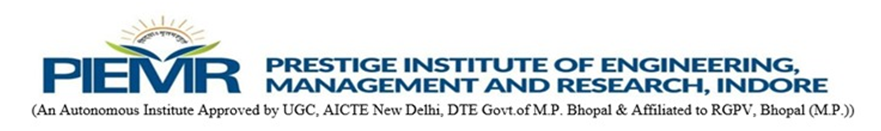

<h2 align="left">Department of AI & Data Science</h2>

<h2 align="left">Data Mining & Warehousing Lab </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>


<h2 align="left">Experiment 8</h2>


<h2 align="left">Probabilistic Classification using Bayesian Learning</h2>

<h2 align="left">Objective</h2>

To implement Probabilistic Classification using the Naive Bayes Algorithm on the Diabetes Dataset and predict whether a patient is diabetic or non-diabetic.

P(A|B)=P(B|A)P(A)/P(B)


Python Libraries Used

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



STEP 1: Load Dataset

Dataset Path

C:\Users\rjesh\diabetes.csv

In [2]:
path = r"C:\Users\rjesh\diabetes.csv"

df = pd.read_csv(path)

print(df.head())




   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


STEP 2: Explore Dataset

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Information:\n")
print(df.info())




Dataset Shape: (768, 9)

Columns:

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Dataset Features


| Feature                  | Meaning                        |
| ------------------------ | ------------------------------ |
| Pregnancies              | Number of pregnancies          |
| Glucose                  | Blood glucose level            |
| BloodPressure            | Blood pressure                 |
| SkinThickness            | Skin fold thickness            |
| Insulin                  | Insulin level                  |
| BMI                      | Body mass index                |
| DiabetesPedigreeFunction | Diabetes inheritance score     |
| Age                      | Age of patient                 |
| Outcome                  | 0 = Non-diabetic, 1 = Diabetic |





STEP 3: Visualize Dataset

Glucose Distribution



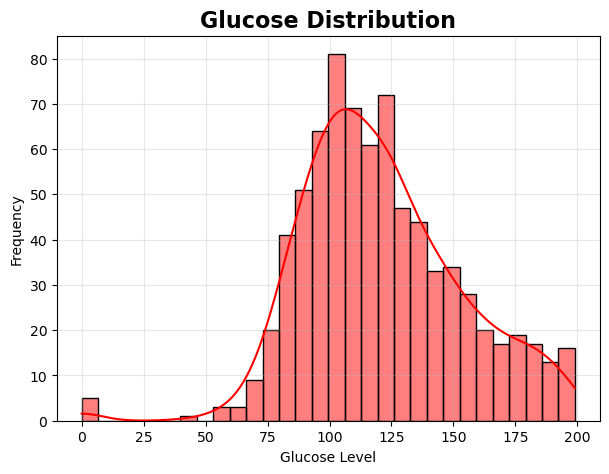

In [4]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Glucose'],
    bins=30,
    kde=True,
    color='red'
)

plt.title(
    "Glucose Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Glucose Level")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()




BMI Distribution

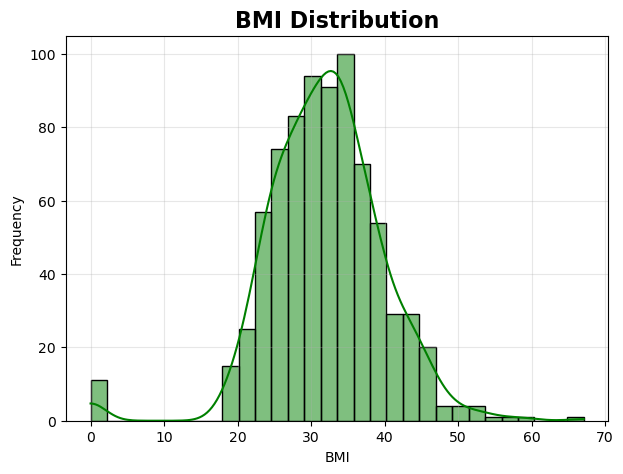

In [5]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['BMI'],
    bins=30,
    kde=True,
    color='green'
)

plt.title(
    "BMI Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()




Age Distribution

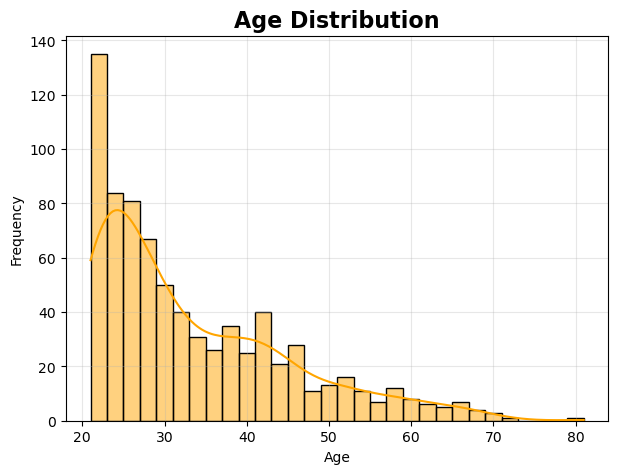

In [6]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title(
    "Age Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()




Outcome Distribution

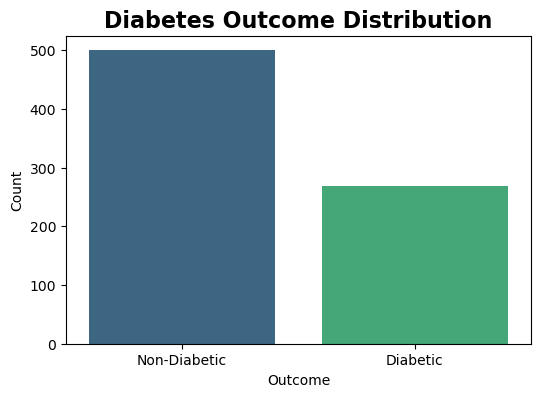

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['Outcome'],
    palette='viridis'
)

plt.title(
    "Diabetes Outcome Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Outcome")
plt.ylabel("Count")

plt.xticks([0,1], ['Non-Diabetic','Diabetic'])

plt.show()




Correlation Heatmap

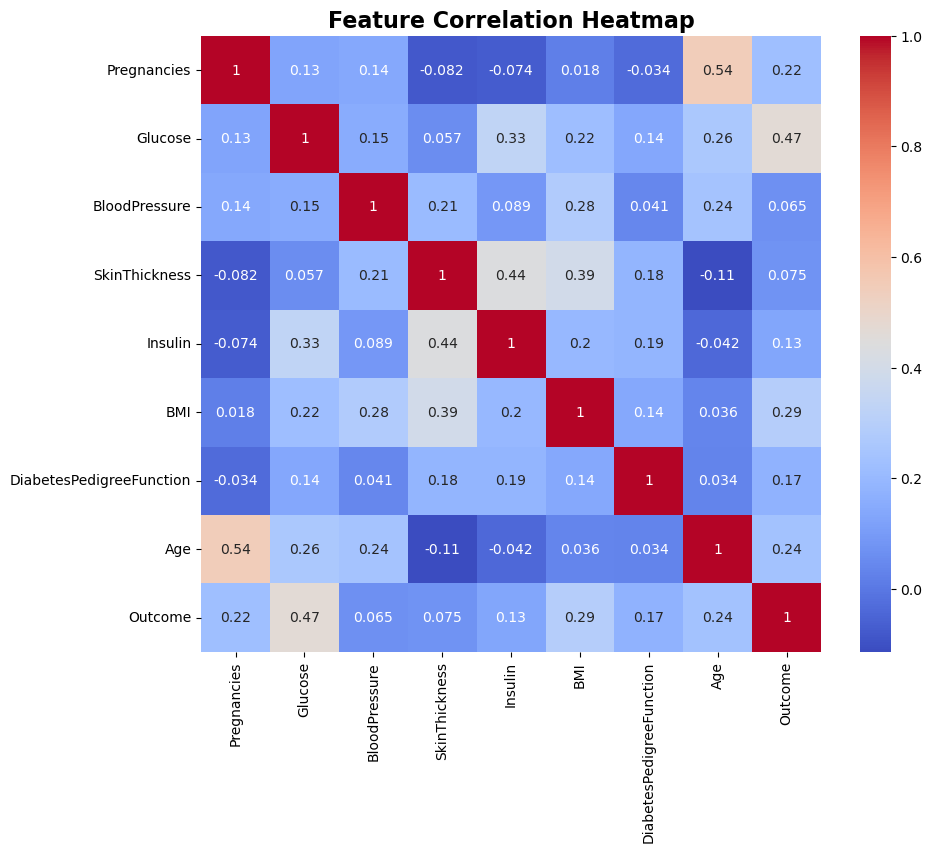

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=16,
    fontweight='bold'
)

plt.show()




STEP 4: Split Features and Target

In [9]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']




Explanation

| Variable | Meaning        |
| -------- | -------------- |
| X        | Input Features |
| y        | Target Class   |


STEP 5: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




Explanation

| Parameter       | Meaning              |
| --------------- | -------------------- |
| test_size=0.2   | 20% testing data     |
| random_state=42 | Reproducible results |





STEP 6: Create Bayesian Model

Algorithm Used:

Gaussian Naive Bayes

In [11]:
model = GaussianNB()

Why GaussianNB?

Because:

dataset contains continuous numerical values

Gaussian distribution assumption works well

STEP 7: Train Model

In [12]:
model.fit(X_train, y_train)



,priors,None
,var_smoothing,1e-09


model.fit(X_train, y_train)

In [13]:
y_pred = model.predict(X_test)


STEP 9: Accuracy Calculation

Accuracy Formula


Accuracy=
Total Predictions / Correct Predictions



In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)



Accuracy: 0.7662337662337663


STEP 10: Confusion Matrix

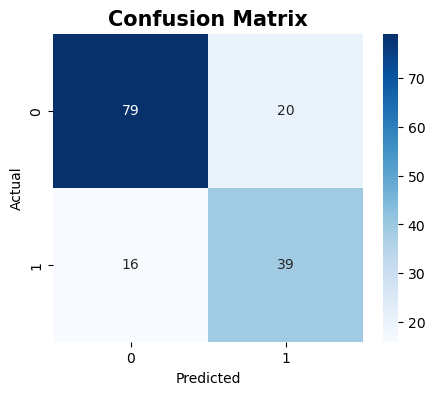

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.show()



STEP 11: Classification Report

In [16]:
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



STEP 12: Probability Prediction

Naive Bayes can predict probabilities.

In [17]:
probabilities = model.predict_proba(X_test)

print(probabilities[:5])



[[0.73024358 0.26975642]
 [0.93694781 0.06305219]
 [0.96883655 0.03116345]
 [0.81484811 0.18515189]
 [0.45359983 0.54640017]]


Explanation

Output example:
[0.85 0.15]

Meaning:

85% probability = Non-diabetic

15% probability = Diabetic


STEP 13: Visualize Prediction Results

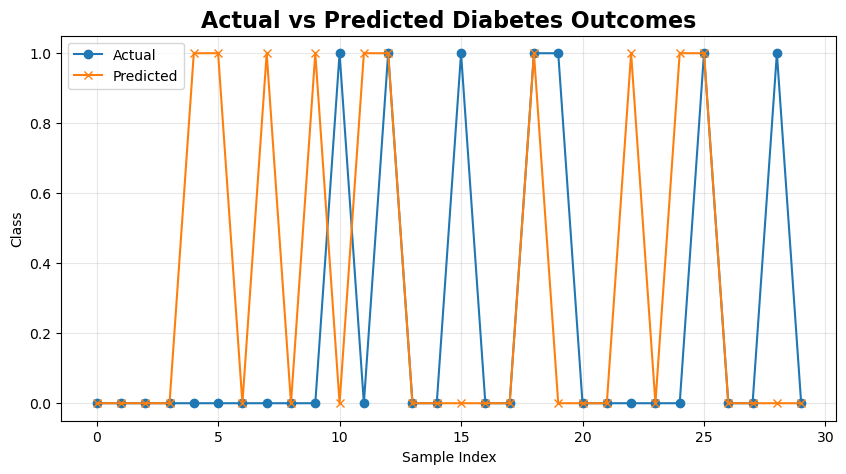

In [18]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:30], label='Actual', marker='o')

plt.plot(y_pred[:30], label='Predicted', marker='x')

plt.title(
    "Actual vs Predicted Diabetes Outcomes",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Sample Index")
plt.ylabel("Class")

plt.legend()

plt.grid(alpha=0.3)

plt.show()




Final Result

The Gaussian Naive Bayes classifier successfully performed probabilistic classification on the diabetes dataset and predicted diabetic outcomes with good accuracy.


Advantages

Fast training

Works well with medical datasets

Probability-based prediction

Easy implementation



Limitations

Assumes feature independence

Performance decreases if features are highly correlated


Viva Questions

Q1. What is Bayesian Learning?


Bayesian Learning uses probability theory for prediction and classification.


Q2. What is Naive Bayes?


Naive Bayes is a probabilistic classifier based on Bayes Theorem.


Q3. Why is it called “Naive”?


Because it assumes all features are independent.


Q4. Why GaussianNB was used?

Because the dataset contains continuous numerical features.

Q5. What is posterior probability?


Probability after observing evidence.






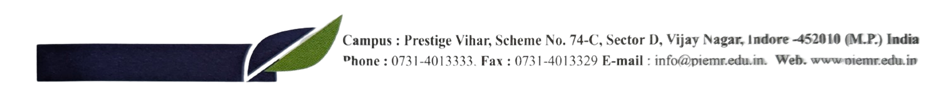